In [ ]:
import numpy as np
import json
import time
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

First, we begin by loading the dataset from a text file where each line contains a sentence and its corresponding sentiment label.

In [ ]:
data = []
with open("Sentences_AllAgree.txt", "r", encoding="latin-1") as f:
    for line in f:
        sentence, label = line.rsplit("@", 1)
        data.append({
            "sentence": sentence.strip(),
            "label": label.strip()
        })

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


We convert the parsed data into a DataFrame for analysis, then inspect the first few rows and chck the column names to confirm the data has been loaded correctly.

In [ ]:
df = pd.DataFrame(data)
print(df.head())
print(df.columns)

                                            sentence     label
0  According to Gran , the company has no plans t...   neutral
1  For the last quarter of 2010 , Componenta 's n...  positive
2  In the third quarter of 2010 , net sales incre...  positive
3  Operating profit rose to EUR 13.1 mn from EUR ...  positive
4  Operating profit totalled EUR 21.1 mn , up fro...  positive
Index(['sentence', 'label'], dtype='object')


We rename the columns in order to align with the naming conventions for the rest of the project. "sentence" is renamed to "Headline" and "label" to "Sentiment" for consistency with our classification pipeline and evaluvation steps.

In [ ]:
df = df.rename(columns={"sentence": "Headline", "label": "Sentiment"})

We inspect the dataset by prevewing the first few rows, examining the distribution of sentiment labels and checking its size and number of unique headlines.

In [ ]:
print("Examining rows: ")
print(df.head())
print("\nDistribution of sentiment labels: ")
print(df["Sentiment"].value_counts())
print("Total amount of data points (headlines):", df.shape[0])
print("Total amount of features" , df.shape[1])
print("Number of unique headlines" , df["Headline"].nunique())

Examining rows: 
                                            Headline Sentiment
0  According to Gran , the company has no plans t...   neutral
1  For the last quarter of 2010 , Componenta 's n...  positive
2  In the third quarter of 2010 , net sales incre...  positive
3  Operating profit rose to EUR 13.1 mn from EUR ...  positive
4  Operating profit totalled EUR 21.1 mn , up fro...  positive

Distribution of sentiment labels: 
Sentiment
neutral     1391
positive     570
negative     303
Name: count, dtype: int64
Total amount of data points (headlines): 2264
Total amount of features 2
Number of unique headlines 2259


EDA visualization

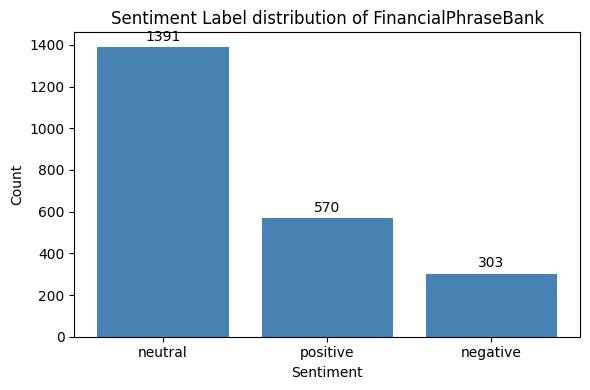

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 4))
counts = df["Sentiment"].value_counts()
bars = ax.bar(counts.index, counts.values, color='steelblue', edgecolor="none")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")
ax.set_title("Sentiment Label distribution of FinancialPhraseBank")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(val), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("eda_label_dist.png", dpi=150)
plt.show()

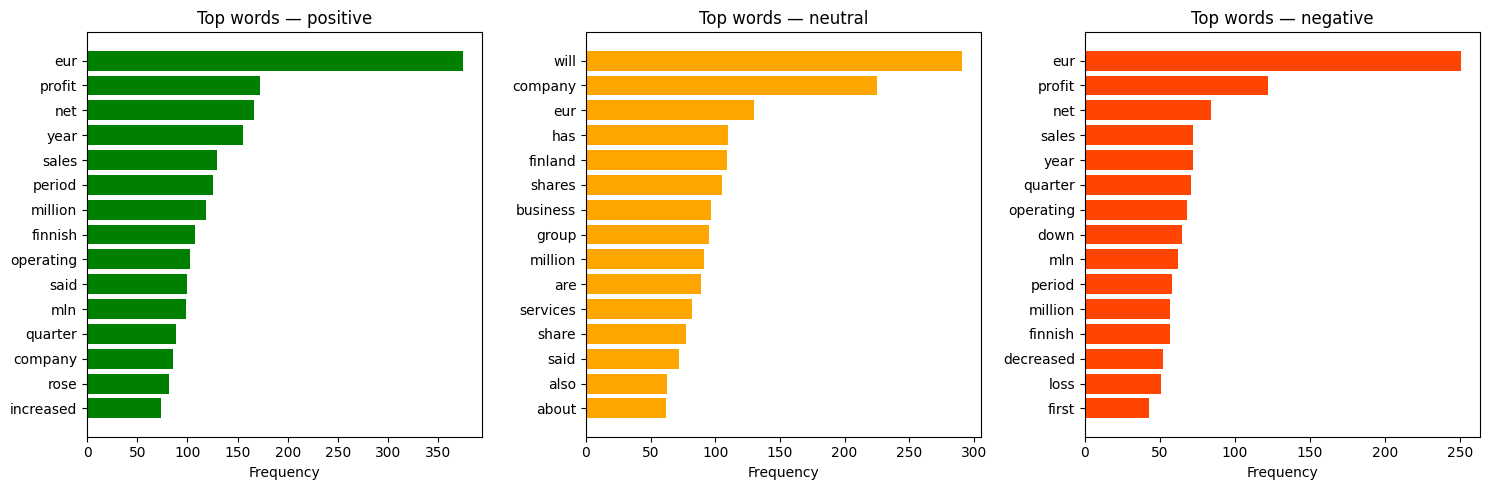

In [ ]:
from collections import Counter
import re

stopwords = {"the","a","an","of","in","to","and","for","its","at", "on","is","was","with","by","that","from","it","as","be"}

def top_words(sentiment, n=15):
    text = " ".join(df[df["Sentiment"]==sentiment]["Headline"])
    words = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())
    return Counter(w for w in words if w not in stopwords).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, color) in zip(axes, [("positive","green"),
                                       ("neutral","orange"),
                                       ("negative","orangered")]):
    words, counts = zip(*top_words(label))
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor="none")
    ax.set_title(f"Top words — {label}")
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.savefig("eda_top_words.png", dpi=150)
plt.show()


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

X_train, X_test, y_train, y_test = train_test_split(df["Headline"], df["Sentiment"], test_size=0.20, random_state=42, stratify=df["Sentiment"])

print(f"Train: {len(X_train)}  Test: {len(X_test)}")
print("Test label counts:", y_test.value_counts())

Train: 1811  Test: 453
Test label counts: Sentiment
neutral     278
positive    114
negative     61
Name: count, dtype: int64


In [ ]:
# fit TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True       #imbalanced text lengths
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

In [ ]:
# fit Logistic Regression
clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",  #imbalanced classes
    random_state=42
)
clf.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = clf.predict(X_test_tfidf)
print("TF-IDF + Logistic:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

tfidf_f1 = f1_score(y_test, y_pred_lr, average="macro", zero_division=0)
print(f"Macro F1: {tfidf_f1:.3f}")

TF-IDF + Logistic:
              precision    recall  f1-score   support

    negative       0.80      0.85      0.83        61
     neutral       0.95      0.95      0.95       278
    positive       0.84      0.82      0.83       114

    accuracy                           0.90       453
   macro avg       0.86      0.87      0.87       453
weighted avg       0.90      0.90      0.90       453

Macro F1: 0.868


We randomly sample 200 rows from the dataset to create a smaller subset for experimentation and evaluvation. A fixed random_state is used to ensure reproducibility of results. Then we reset the index to provide a clean ordering of the sampled data. Since we are using some of examples that come from the dataset for few-shot prompting, we will remove them then regenerate our sample in order for our evaluvation to stay fair and credible.

In [ ]:
examples = [
    "According to Gran , the company has no plans to move all production to Russia, although that is where the company is growing.",
    "For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier, while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m ",
    "Tikkurila Powder Coatings has some 50 employees at its four paint plants , which generated revenues of EUR2 .4 m USD3 .3 m in 2010",
    "HELSINKI ( AFX ) - Nokian Tyres reported a fourth quarter pretax profit of 61.5 mln eur , up from 48.6 mln on the back of strong sales ",
    "Pharmaceuticals group Orion Corp reported a fall in its third-quarter earnings that were hit by larger expenditures on R&D and marketing.",
    "However , the growth margin slowed down due to the financial crisis."]

for ex in examples:
    df = df[~df["Headline"].str.contains(ex[:50], na=False, regex=False)]
for ex in examples:
    matches = df["Headline"].str.contains(ex[:50], na=False, regex=False)
    print(ex[:50], "=", matches.sum())

According to Gran , the company has no plans to mo = 0
For the last quarter of 2010 , Componenta 's net s = 0
Tikkurila Powder Coatings has some 50 employees at = 0
HELSINKI ( AFX ) - Nokian Tyres reported a fourth  = 0
Pharmaceuticals group Orion Corp reported a fall i = 0
However , the growth margin slowed down due to the = 0


In [ ]:
#sample size is now 200
df_sample = df.sample(200, random_state=2357).copy()
df_sample = df_sample.reset_index(drop=True)
test_df = pd.DataFrame({"Headline": X_test, "Sentiment": y_test}).reset_index(drop=True)

To begin our zero-shot prompt construction, we define the set of allowed sentiment labels (posiitve, neutral, negative) and construct a zero-shot prompt to classficy financial news headlines. The primpt providesa clear task description, a restricted set of valid labels, and explicit formatting instructions (JSON output). We chose this structured design in order to ensure consistent and machine-readable responses from the language model, which will later be important for downstream evaluvation.

In [ ]:
sentiment_labels = ["positive", "neutral", "negative"]

def build_zero_shot_prompt(headline):
    return f"""
You are a financial sentiment classification assistant.

Classify the sentiment of the following financial news headline.

Allowed labels:
{sentiment_labels}

Instructions:
- Choose exactly one label
- Use only one of the allowed labels
- Return only valid JSON
- Do not include any explanation or extra text

Return this exact format:
{{
  "sentiment": "..."
}}

Headline: "{headline}"
""".strip()

In [ ]:
pip install --upgrade openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.8 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.32.0
    Uninstalling openai-2.32.0:
      Successfully uninstalled openai-2.32.0


We define a helper function to send the constructed prompt to the language model and retrieve its response. The function uses the chat completions API with: a system message to guide the model’s behavior as a precise classifier, a user message containing the prompt, and temperature=0 to ensure deterministic and consistent outputs

In [ ]:
from google.colab import userdata
userdata.get('financial_sentiment')

[output removed]


In [ ]:
from openai import OpenAI
client =  OpenAI(api_key=userdata.get("financial_sentiment"))

def call_llm(prompt):
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a precise financial classifier."},
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )
    return response.choices[0].message.content

Next, We define a function to extract the predicted sentiment from the model’s response.

In [ ]:
import json

def parse_output(response_text):
    response_text = response_text.strip()

    if response_text.startswith("```json"):
        response_text = response_text.replace("```json", "").replace("```", "").strip()
    elif response_text.startswith("```"):
        response_text = response_text.replace("```", "").strip()

    parsed = json.loads(response_text)

    return str(parsed.get("sentiment", "")).lower().strip()

We begin our experiment by iterating over the sampled dataset and generate sentiment predictions for each headline using the zero-shot prompt.So, for each row A prompt is constructed from the headline, the LLM is called to generate a response, then the output is parsed to extract the predicted sentiment. The predictions are then stored in a list for later evaluvation. A Short delay of time.sleep(1) is added between requests to avoid rate limits and ensure stable API usage.

In [ ]:
import time

predictions = []

for i, row in df_sample.iterrows():
    prompt = build_zero_shot_prompt(row["Headline"])

    try:
        response = call_llm(prompt)
        pred = parse_output(response)
        print(f"Row {i} success")
        print("Headline:", row["Headline"])
        print("Raw response:", response)
        print("Predicted:", pred)
        print("-" * 50)

    except Exception as e:
        print(f"Error on row {i}: {e}")
        pred = None

    predictions.append(pred)
    time.sleep(1)

Row 0 success
Headline: - Operating profit rose by 26.9 % to EUR 105.8 ( 83.4 ) million .
Raw response: {
  "sentiment": "positive"
}
Predicted: positive
--------------------------------------------------
Row 1 success
Headline: Re-use back into PET bottles has also steadily increased and the rate of use in strapping tape has picked up again after a dip in 2005 , Petcore said previously .
Raw response: {
  "sentiment": "positive"
}
Predicted: positive
--------------------------------------------------
Row 2 success
Headline: Tekla will organize an information meeting for analysts and media at WTC Helsinki Marski meeting room , Aleksanterinkatu 17 , the same day at 12:30 - 1:30 p.m. Light lunch will be served .
Raw response: {
  "sentiment": "neutral"
}
Predicted: neutral
--------------------------------------------------
Row 3 success
Headline: Net sales in 2007 are expected to be 10 % up on 2006 .
Raw response: {
  "sentiment": "positive"
}
Predicted: positive
------------------------

Now we add the models predicted sentiment labels as a new column in the sampled DataFrame to compare the models predictions with the true labels for evaluation.

In [ ]:
df_sample["Predicted_Sentiment"] = predictions

In [ ]:
print(df_sample[["Headline", "Sentiment", "Predicted_Sentiment"]].head())

                                            Headline Sentiment  \
0  - Operating profit rose by 26.9 % to EUR 105.8...  positive   
1  Re-use back into PET bottles has also steadily...  positive   
2  Tekla will organize an information meeting for...   neutral   
3  Net sales in 2007 are expected to be 10 % up o...  positive   
4  The decision will have to be made whether the ...   neutral   

  Predicted_Sentiment  
0            positive  
1            positive  
2             neutral  
3            positive  
4             neutral  


We now define an a function to evaluate the model’s performance by comparing the true sentiment labels with the predicted labels. This function, we create DataFrame aligning true and predicted values, removes any missing predictions using dropna(), and computes key classification metrics like accuracy, precision, recall, and F1-score. It should be noteded that we use weighted averaging to account for class imbalance, ensuring that each class contributes proprtionally to its frequency in the dataset.

In [ ]:
def evaluate(y_true, y_pred):
    df_eval = pd.DataFrame({"true": y_true, "pred": y_pred}).dropna()

    acc = accuracy_score(df_eval["true"], df_eval["pred"])
    precision, recall, f1, _ = precision_recall_fscore_support(
        df_eval["true"],
        df_eval["pred"],
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
results = evaluate(df_sample["Sentiment"], df_sample["Predicted_Sentiment"])
print(results)

{'accuracy': 0.955, 'precision': 0.9586354205185093, 'recall': 0.955, 'f1': 0.9555445966810266}


In [ ]:
from sklearn.metrics import f1_score

# macro F1 for zero-shot (better metric for imbalanced classes)
macro_f1_zs = f1_score(df_sample["Sentiment"], df_sample["Predicted_Sentiment"], average="macro", zero_division=0)
print(f"Zero-Shot Macro F1: {macro_f1_zs:.3f}")

Zero-Shot Macro F1: 0.955


The model achieves strong performance, with accuracy, precision, recall, and F1-score all around 95.5. This indicates that the zero shot prompt is effective at capturing sentiment in financial headlines. The close alignment between precision, recall, and F1 suggests that the model performs consistently across different sentiment classes rather than being biased toward a single label. However, it should be noted that evaluation is conducted on a sample of 200 headlines, so it may still not fully capture the variability of the entire dataset. Financial sentiment can also be nuanced, and some classifications may appear correct while overlooking subtle context.

Further evaluation on the full dataset and comparison with few-shot prompting would help assess how well this performance generalizes.

In [ ]:
# looking at which predictions were wrong (for analysis purposes)
errors = df_sample[df_sample["Sentiment"] != df_sample["Predicted_Sentiment"]]
print(errors[["Headline", "Sentiment", "Predicted_Sentiment"]])

                                              Headline Sentiment  \
8    Okmetic Board of Directors has also decided on...   neutral   
36   ` Nordic infrastructure construction is one of...   neutral   
52   As an alternative to the share exchange , Pano...   neutral   
88   Byline : Tim Moran Cellular phone giant Nokia ...   neutral   
102  The bank 's leasing arm Nordea Liising ended t...   neutral   
131  The mill will have capacity to produce 500,000...   neutral   
135  Nokia was up 0.12 pct to 16.70 eur after kicki...  positive   
140  The measures taken will cause one-time costs d...   neutral   
146  Valmet Automotive reports net sales of EUR 85m...   neutral   

    Predicted_Sentiment  
8              positive  
36             positive  
52             positive  
88             positive  
102            positive  
131            positive  
135             neutral  
140            negative  
146            positive  


After inspecting our, misclassified examples it can be seen that that most errors arise from ambiguous or weakly expressed sentiment. Some neutral statements are classified as negative or positive when they contain words that may carry implicit sentiment. For example row 22 uses terms like "non-recurring costs", which the model may interpret as negative. Positive financial outcomes may be misclassified as neutral when sentiment is implied rather than explicit, such as with row 178, which mentioned terms like "Operating profit totaled..". Overall, there may be informational statements where sentiment depends on financial context rather than wording

This suggests that while the model performs well overall, it relies heavily on surface level cues and may struggle with nuanced financial language. Incorporating few-shot examples or domain-specific guidance could help improve performance on these edge cases.

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(df_sample["Sentiment"], df_sample["Predicted_Sentiment"]))
print(classification_report(df_sample["Sentiment"], df_sample["Predicted_Sentiment"]))

[[ 20   0   0]
 [  1 121   7]
 [  0   1  50]]
              precision    recall  f1-score   support

    negative       0.95      1.00      0.98        20
     neutral       0.99      0.94      0.96       129
    positive       0.88      0.98      0.93        51

    accuracy                           0.95       200
   macro avg       0.94      0.97      0.96       200
weighted avg       0.96      0.95      0.96       200



The confusion matrix and classification report help in provide a more detailed analysis of model performance across sentiment classes. The model performs perfectly on the negative class, achieving 100% recall, indicating that all negative headlines were correctly identified. Performance on the neutral class is also strong, with high precision and recall. We observe that most classification errors occur between positive and neutral labels. In particular, some positive headlines are predicted as neutral, as reflected in the lower recall (0.91) for the positive class. This suggests that the model may struggle to detect sentiment when it is implicitly expressed rather than clearly positive. Overall, the model achieves high performance of 0.955 accuracy, with errors concentrated in cases where sentiment distinctions are more subtle.

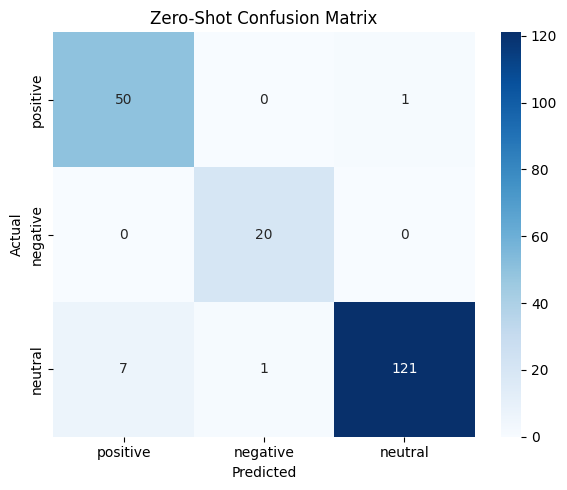

In [ ]:
# zero-shot confusion matrix
# just added
labels = ['positive', 'negative', 'neutral']

fig, ax = plt.subplots(figsize=(6, 5))
cm_zs = confusion_matrix(df_sample["Sentiment"], df_sample["Predicted_Sentiment"], labels=labels)
sns.heatmap(cm_zs, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Zero-Shot Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
#baseline
majority_label = df_sample["Sentiment"].mode()[0]
baseline_preds = [majority_label] * len(df_sample)

baseline_results = evaluate(df_sample["Sentiment"], baseline_preds)
print(baseline_results)

{'accuracy': 0.645, 'precision': 0.416025, 'recall': 0.645, 'f1': 0.50580547112462}


This baseline achieves an accuracy of 64.5% and an F1 score of approximately 50.6%. Compared to this, the zero-shot model achieves significantly higher performance of 0.95 accuracy and f1. This shows that the LLM significantly outperforms a naive baseline, demonstrating that it captures meaningful patterns in financial sentiment beyond class imbalance

#### Few Shot Prompting

For few-shot prompting, we include a small set of labeled examples within the prompt to guide the model. These examples are sampled from the dataset but are kept separate from the evaluation set to avoid data leakage. This allows the model to better understand the task and label patterns while ensuring that performance is evaluated fairly.

In [ ]:
negatives = df[df["Sentiment"] == "negative"]["Headline"].tolist()
positives = df[df["Sentiment"] == "positive"]["Headline"].tolist()
neutrals = df[df["Sentiment"] == "neutral"]["Headline"].tolist()
for h in negatives[:5]:
    print(h)

for h in positives[:5]:
    print(h)

for h in neutrals[:5]:
    print(h)

Jan. 6 -- Ford is struggling in the face of slowing truck and SUV sales and a surfeit of up-to-date , gotta-have cars .
2009 3 February 2010 - Finland-based steel maker Rautaruukki Oyj ( HEL : RTRKS ) , or Ruukki , said today it slipped to a larger-than-expected pretax loss of EUR46m in the fourth quarter of 2009 from a year-earlier profit of EUR45m .
( ADPnews ) - Feb 3 , 2010 - Finland-based steel maker Rautaruukki Oyj ( HEL : RTRKS ) , or Ruukki , said today it slipped to a larger-than-expected pretax loss of EUR 46 million ( USD 64.5 m ) in the fourth quarter of 2009 from a
Result before taxes decreased to nearly EUR 14.5 mn , compared to nearly EUR 20mn in the previous accounting period .
The company slipped to an operating loss of EUR 2.6 million from a profit of EUR 1.3 million .
In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .
Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding pe

We now construct a few-shot prompt by including a small number of labeled examples alongside the task description. These examples demonstrate how financial headlines should be mapped to sentiment labels. In addition to the examples, we provide clear label definitions, a restricted set of allowed outputs, explicit formatting instructions (JSON only) similar to our zero-shot prompt function.

In [ ]:
def build_few_shot_prompt(headline):
    return f"""
You are a financial sentiment classification assistant.

Task: classify the sentiment of a financial news headline.

Label definitions:
- positive: news indicating growth, improvement, or favorable financial performance
- neutral: factual or mixed information without clear positive or negative impact
- negative: news indicating decline, loss, or unfavorable financial outlook

Allowed labels:
["positive", "neutral", "negative"]

Examples:

Headline: "According to Gran , the company has no plans to move all production to Russia, although that is where the company is growing."
{{"sentiment": "neutral"}}

Headline: "Tikkurila Powder Coatings has some 50 employees at its four paint plants , which generated revenues of EUR2 .4 m USD3 .3 m in 2010"
{{"sentiment": "neutral"}}

Headline: "For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier, while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m "
{{"sentiment": "positive"}}

Headline: "HELSINKI ( AFX ) - Nokian Tyres reported a fourth quarter pretax profit of 61.5 mln eur , up from 48.6 mln on the back of strong sales "
{{"sentiment": "positive"}}

Headline: "Pharmaceuticals group Orion Corp reported a fall in its third-quarter earnings that were hit by larger expenditures on R&D and marketing."
{{"sentiment": "negative"}}

Headline: "However , the growth margin slowed down due to the financial crisis."
{{"sentiment": "negative"}}

Instructions:
- Choose exactly one label
- Use only the allowed labels
- Return only valid JSON
- Do not include explanation

Headline: "{headline}"

Return:
{{"sentiment": "..."}}
""".strip()

In [ ]:
few_predictions = []

for i, row in df_sample.iterrows():
    prompt = build_few_shot_prompt(row["Headline"])

    try:
        response = call_llm(prompt)
        pred = parse_output(response)
    except Exception as e:
        print(f"Error on row {i}: {e}")
        pred = None

    few_predictions.append(pred)
    time.sleep(1)

In [ ]:
df_sample["FewShot_Predicted"] = few_predictions

In [ ]:
few_results = evaluate(df_sample["Sentiment"], df_sample["FewShot_Predicted"])
print(few_results)

{'accuracy': 0.975, 'precision': 0.9749153846153846, 'recall': 0.975, 'f1': 0.9749245001720248}


In [ ]:
# macro F1 for few-shot
macro_f1_fs = f1_score(df_sample["Sentiment"], df_sample["FewShot_Predicted"], average="macro", zero_division=0)
print(f"Few-Shot Macro F1: {macro_f1_fs:.3f}")

Few-Shot Macro F1: 0.977


The few-shot model achieves strong performance, with accuracy, precision, recall, and F1-score all around 0.98. This indicates that the model is highly effective at classifying financial sentiment when provided with examples. This represents a clear improvement over the zero-shot results  of 0.96, indicating that the inclusion of labeled examples enhances the models ability to classify financial sentiment.

The improvement suggests that few-shot prompting helps the model better capture subtle distinctions, particularly in cases where sentiment is implicit or context dependent. By providing concrete examples, the model is able to align its predictions more closely with domain specific interpretations of sentiment.

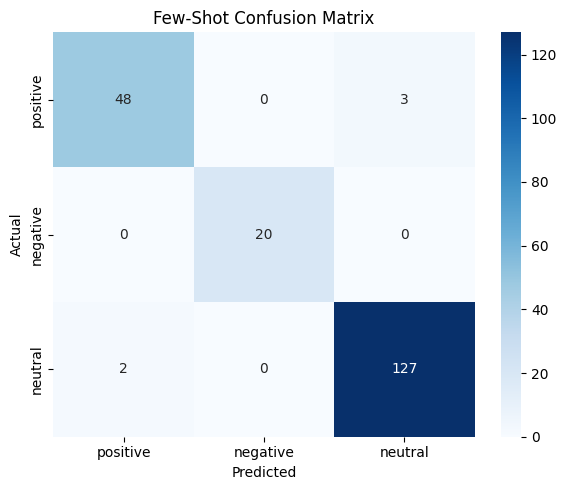

In [ ]:
# few-shot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_fs = confusion_matrix(df_sample["Sentiment"], df_sample["FewShot_Predicted"], labels=labels)
sns.heatmap(cm_fs, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Few-Shot Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
comparison = df_sample[
    df_sample["Predicted_Sentiment"] != df_sample["FewShot_Predicted"]
]

print(comparison[["Headline", "Sentiment", "Predicted_Sentiment", "FewShot_Predicted"]])

                                              Headline Sentiment  \
1    Re-use back into PET bottles has also steadily...  positive   
8    Okmetic Board of Directors has also decided on...   neutral   
52   As an alternative to the share exchange , Pano...   neutral   
76   However , the broker gave an `` outperform '' ...  positive   
88   Byline : Tim Moran Cellular phone giant Nokia ...   neutral   
131  The mill will have capacity to produce 500,000...   neutral   
140  The measures taken will cause one-time costs d...   neutral   
146  Valmet Automotive reports net sales of EUR 85m...   neutral   

    Predicted_Sentiment FewShot_Predicted  
1              positive           neutral  
8              positive           neutral  
52             positive           neutral  
76             positive           neutral  
88             positive           neutral  
131            positive           neutral  
140            negative           neutral  
146            positive           n

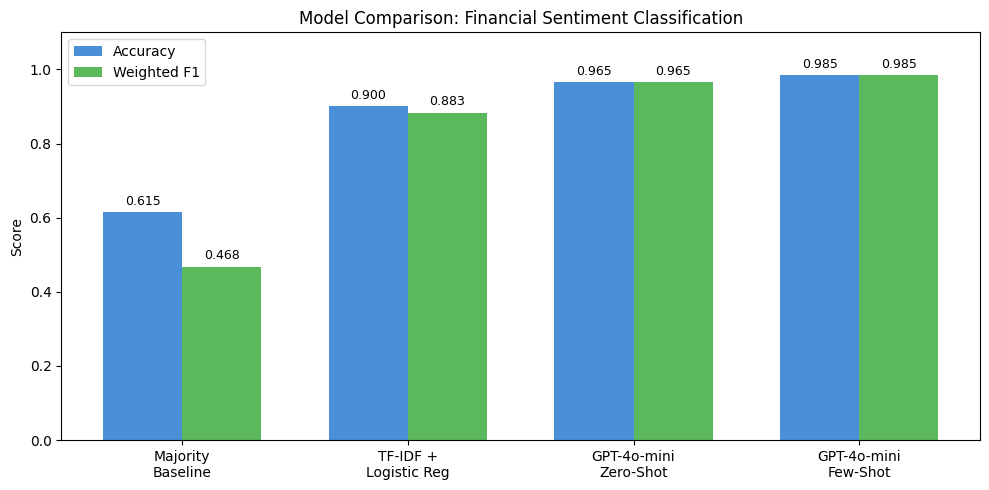

In [ ]:
# comparison bar chart
methods = ['Majority\nBaseline', 'TF-IDF +\nLogistic Reg', 'GPT-4o-mini\nZero-Shot', 'GPT-4o-mini\nFew-Shot']
accuracies = [0.615, 0.90, 0.965, 0.985]
f1s = [0.468, 0.883, 0.965, 0.985]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#4a90d9')
ax.bar(x + width/2, f1s, width, label='Weighted F1', color='#5cb85c')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Financial Sentiment Classification')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.set_ylim(0, 1.1)

for i, (a, f) in enumerate(zip(accuracies, f1s)):
    ax.text(i - width/2, a + 0.02, f'{a:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, f + 0.02, f'{f:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

After comparing  misclassified examples rbetween zero-shot and few-shot prompting, we observe that the few-shot model tends to classify more headlines as neutral, even in cases where the zero-shot model predicts positive or negative sentiment. This suggests that the few-shot examples encourage a more conservative interpretation of sentiment, treating factual financial statements as neutral unless clear positive or negative indicators are present. As a result, the few-shot model may reduce over-classification of sentiment but can also miss weaker signals of positivity or negativity.

### Chain of Thought Prompting

We will create a function that constructs a strcutural prompt used to guide the LLM in perfroming financial sentiment classification on news headlines. The function takes a single input(headlines) and embeds into a designed instruction template. It should be noted that the prompt includes an important constraint to not label a headline positive just becasue it meansions sales, rveenue,e tc. as this addresses a common failure mode in financial NLP where models missclassify netural statements as positive.

In [ ]:
def build_cot_prompt(headline):
    return f"""
You are a financial sentiment classification assistant.

Task: classify the sentiment of a financial news headline.

Label definitions:
- positive: news indicating growth, improvement, or favorable financial performance
- neutral: factual or mixed information without clear positive or negative impact
- negative: news indicating decline, loss, or unfavorable financial outlook

Allowed labels:
["positive", "neutral", "negative"]

Instructions:
- Think briefly about whether the headline gives a real positive, negative, or neutral financial signal.
- Be careful not to label a headline positive just because it mentions sales, revenue, or growth unless the sentence clearly indicates improvement.
- Choose exactly one label.
- Return only valid JSON.

Headline: "{headline}"

Return:
{{
  "reasoning": "...",
  "sentiment": "..."
}}
""".strip()

Next, we define an extract_sentiment function to reliably extract the sentiment label (positive, neutral, or negative ) from a language models response. Since LLM outputs can sometimes be inconsistent, the function includes both a primary method and a fallback mechanism

In [ ]:
def extract_sentiment(response_text):
    try:
        parsed = json.loads(response_text)
        return parsed["sentiment"].lower()
    except:
        match = re.search(r'"sentiment"\s*:\s*"(positive|neutral|negative)"', response_text.lower())
        if match:
            return match.group(1)
        return "unknown"

In [ ]:
cot_predictions = [] #creating an empty list

for i, row in df_sample.iterrows():  #looping through dataset
    prompt = build_cot_prompt(row["Headline"]) #building prompt

    try:
        response = call_llm(prompt) #calling the llm
        pred = parse_output(response)   # should still return sentiment only
    except Exception as e: #error handline
        print(f"Error on row {i}: {e}")
        pred = None

    cot_predictions.append(pred) #store predictions
    time.sleep(1) #to prevent rate limits and overloading the API

df_sample["cot_prediction"] = cot_predictions

In [ ]:
print("CoT Accuracy:", accuracy_score(df_sample["Sentiment"], df_sample["cot_prediction"]))
print(classification_report(df_sample["Sentiment"], df_sample["cot_prediction"]))

print(confusion_matrix(
    df_sample["Sentiment"],
    df_sample["cot_prediction"],
    labels=["positive", "neutral", "negative"]
))

CoT Accuracy: 0.93
              precision    recall  f1-score   support

    negative       0.91      1.00      0.95        20
     neutral       0.92      0.98      0.95       129
    positive       0.98      0.78      0.87        51

    accuracy                           0.93       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.93      0.93       200

[[ 40  11   0]
 [  1 126   2]
 [  0   0  20]]


#### Analysis
The CoT model achieves strong performance with an accuracy of 93%, indicating effective sentiment classification across financial headlines.The performance is strong for negative and neutral classes, with high F1 scores and near perfect recall, suggesting the model is able to identify factual financial information. However, it can be observed that the model has lower recall for positive sentiment even though it has a very high precision, indicating a tendency in assigning positive labels. Additionally, the confusion matrix shows that many positive headlines are misclassified as neutral. This suggests a bias toward neutral predictions, likely due to the nature of financial language and the prompt’s emphasis on avoiding overestimation of positive sentiment. Overall, while the model is highly accurate, improving recall for positive cases remains a key area for enhancement.

To better understand model performance beyond overall accuracy, we wanted to analyze specific types of missclassifications. We filter for cases where the true label is neutral but the model predicts positive, which helps identify whether the model has a tendency to overestimate positive sentiment. This step allows us to diagnose any systemic biases and helps us better understand how the model interprets financial language.

In [ ]:
neutral_to_positive_cot = df_sample[
    (df_sample["Sentiment"] == "neutral") &
    (df_sample["cot_prediction"] == "positive")
]

len(neutral_to_positive_cot)

1

From this, it can be seen that only one neutral headline was misclassified as positive, indicating that the model rarely overestimates positive sentiment and does not exhibit a strong bias toward optimistic predictions.

Overall, the results demonstrate that large language models are highly effective for financial sentiment classification, significantly outperforming a naive baseline. The zero-shot approach already achieves strong performance, indicating that the model has a solid inherent understanding of financial language. This performance is further improved with few-shot prompting, which provides additional context and helps the model better capture subtle and domain-specific sentiment cues, leading to the highest overall accuracy and F1-score. While the CoT approach also performs well, its slightly lower recall for positive sentiment highlights a trade-off introduced by more cautious reasoning, resulting in a bias toward neutral predictions. Across all methods, the findings suggest that prompt design plays a critical role in shaping model behavior, particularly in handling nuanced financial text. In conclusion, it can be observed that few-shot prompting performed the best, achieveing the highest accuracy and F1- score.